# **Child Well-being — Dominance & Separation Matrices**
**University: University of Milano-Bicocca**  
**Master's Degree: Data Science (A.Y. 2025/2026)**  
**Course: Data Science Lab**

---

Build POSets from the four selected datasets and compute dominance and separation matrices  
between OECD countries (`REF_AREA`) for each poset.

Three types of matrix are produced for each dataset:

| Matrix | Symbol | Meaning |
|--------|--------|---------|
| **Certain** | `D_cert[i,j] = 1` | country *i* is **certainly** ≤ country *j* in every scenario |
| **Possible** | `D_poss[i,j] = 1` | country *i* is **possibly** ≤ country *j* in at least one scenario |
| **Separation** | `Sep[i,j] ∈ [0,1]` | expected normalised rank distance between *i* and *j* over all linear extensions |

In [15]:
import sys; sys.path.insert(0, '..')

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import poset as P

---
## 1. Datasets

| Key | File | Indicators | Levels | Year |
|-----|------|------------|--------|------|
| `exp_4lev_2015` | `040_public_expenditure_dim_discrete_4_level_2015.parquet` | C2, C3, C4, C5 | 4 | 2015 |
| `exp_3lev_2018` | `040_public_expenditure_dim_discrete_3_level_2018.parquet` | C2, C3, C4, C5 | 4 | 2018 |
| `ind_macro_3lev_2015` | `040_indicators_macro_dim_3_level_2015.parquet` | material, health, education, social | 3 | 2015 |
| `ind_macro_3lev_2018` | `040_indicators_macro_dim_3_level_2018.parquet` | material, health, education, social | 3 | 2018 |

In [16]:
DATASETS = {
    "exp_4lev_2015": {
        "path": "../data/040_public_expenditure_dim_discrete_4_level_2015.parquet",
        "label": "Public Expenditure — 4 levels (2015)",
    },
    "exp_4lev_2018": {
        "path": "../data/040_public_expenditure_dim_discrete_4_level_2018.parquet",
        "label": "Public Expenditure — 4 levels (2018)",
    },
    "ind_macro_3lev_2015": {
        "path": "../data/040_indicators_macro_dim_3_level_2015.parquet",
        "label": "Indicators Macro-dim — 3 levels (2015)",
    },
    "ind_macro_3lev_2018": {
        "path": "../data/040_indicators_macro_dim_3_level_2018.parquet",
        "label": "Indicators Macro-dim — 3 levels (2018)",
    },
}

dfs = {}
for key, meta in DATASETS.items():
    dfs[key] = pl.read_parquet(meta["path"])
    df = dfs[key]
    ind_cols = [c for c in df.columns if c not in ("REF_AREA", "TIME_PERIOD")]
    print(f"[{key}] {df.shape[0]} countries × {len(ind_cols)} indicators: {ind_cols}")

[exp_4lev_2015] 16 countries × 4 indicators: ['C2_housing_culture', 'C3_public_health', 'C4_education_childcare', 'C5_environment']
[exp_4lev_2018] 16 countries × 4 indicators: ['C2_housing_culture', 'C3_public_health', 'C4_education_childcare', 'C5_environment']
[ind_macro_3lev_2015] 16 countries × 4 indicators: ['material_protection', 'health_prevention', 'education_skills', 'social_wellbeing']
[ind_macro_3lev_2018] 16 countries × 4 indicators: ['material_protection', 'health_prevention', 'education_skills', 'social_wellbeing']


---
## 2. POSet creation

Each dataset produces two POSets:
- `poset_certain` — strict dominance (`a_hi ≤ b_lo` for all indicators)
- `poset_possible` — relaxed dominance (`a_lo ≤ b_hi` for all indicators)

Since every dataset is already filtered to a single year and contains no nulls,  
the two POSets coincide (all units are points, confidence = 100%).

In [17]:
poset_results = {}

for key, meta in DATASETS.items():
    df = dfs[key]
    ind_cols = [c for c in df.columns if c not in ("REF_AREA", "TIME_PERIOD")]
    result = P.poset_from_polars(
        df,
        col1="REF_AREA",
        indicator_cols=ind_cols,
        higher_is_better=True,
        dominance_mode="certain_or_possible",
    )
    poset_results[key] = result

    n = len(result["elements"])
    n_cert = len(result["dom_certain"])
    n_poss = len(result["dom_possible"])
    n_pairs = n * (n - 1)
    print(
        f"[{key}]  {n} countries | "
        f"certain: {n_cert}/{n_pairs} pairs ({100*n_cert/n_pairs:.1f}%) | "
        f"possible: {n_poss}/{n_pairs} pairs ({100*n_poss/n_pairs:.1f}%)"
    )

[exp_4lev_2015]  16 countries | certain: 86/240 pairs (35.8%) | possible: 86/240 pairs (35.8%)
[exp_4lev_2018]  16 countries | certain: 73/240 pairs (30.4%) | possible: 73/240 pairs (30.4%)
[ind_macro_3lev_2015]  16 countries | certain: 67/240 pairs (27.9%) | possible: 67/240 pairs (27.9%)
[ind_macro_3lev_2018]  16 countries | certain: 69/240 pairs (28.8%) | possible: 69/240 pairs (28.8%)


---
## 3. Dominance matrices — helper functions

In [18]:
def _dominance_heatmap(
    matrix: np.ndarray,
    labels: list,
    title: str,
    ax,
    cmap: str = "Blues",
    vmin: float = 0.0,
    vmax: float = 1.0,
    annot: bool = True,
    fmt: str = ".2f",
    mask_diagonal: bool = True,
    annot_fontsize: int = 7,
    xlabel: str = "Column  (higher in poset)",
    ylabel: str = "Row  (lower in poset)",
):
    """
    Draw a dominance or separation matrix as a seaborn heatmap.

    Matrix convention for dominance: D[i, j] = value  →  row i vs col j.
    For separation: Sep[i, j] = symmetric distance  (no directional interpretation).
    """
    data = matrix.astype(float)
    n = len(labels)
    mask = np.eye(n, dtype=bool) if mask_diagonal else None

    sns.heatmap(
        data,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        annot=annot,
        fmt=fmt,
        annot_kws={"size": annot_fontsize},
        mask=mask,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"shrink": 0.75, "aspect": 20},
        square=True,
    )
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)


def plot_certain_possible(
    result: dict,
    label: str,
    figsize: tuple = (18, 8),
    save_path: str = None,
):
    """
    Side-by-side plot of the certain and possible dominance matrices
    for a single dataset result.
    """
    elements = result["elements"]

    cert_mat = result["poset_certain"].dominance_matrix().astype(float)
    poss_mat = result["poset_possible"].dominance_matrix().astype(float)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    _dominance_heatmap(
        cert_mat, elements,
        title="Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)",
        ax=axes[0], cmap="Blues", vmin=0, vmax=1, fmt=".0f",
    )
    _dominance_heatmap(
        poss_mat, elements,
        title="Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)",
        ax=axes[1], cmap="Oranges", vmin=0, vmax=1, fmt=".0f",
    )

    fig.suptitle(label, fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig, axes


def plot_separation(
    result: dict,
    sep_matrix: np.ndarray,
    label: str,
    figsize: tuple = (10, 8),
    save_path: str = None,
):
    """
    Plot the precomputed posetic symmetric separation matrix.

    Sep[i,j] = E[|rank_i - rank_j|] / (n-1) ∈ [0,1]
    averaged over linear extensions via Bubley-Dyer MCMC.
    High value → i and j rank very differently across all orderings.
    """
    elements = result["elements"]

    fig, ax = plt.subplots(figsize=figsize)
    _dominance_heatmap(
        sep_matrix, elements,
        title="Posetic Separation  —  Sep[i,j] = E[|rank_i − rank_j|] / (n−1)",
        ax=ax, cmap="YlOrRd", vmin=0, vmax=1, fmt=".2f",
        mask_diagonal=False,
        xlabel="Country", ylabel="Country",
    )
    fig.suptitle(f"Separation — {label}", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig, ax


print("Helper functions defined.")

Helper functions defined.


---
## 4. Certain & Possible dominance matrices

**Reading the matrix:**
- `D[row, col] = 1` → the row country is dominated by the column country  
  (row scores lower / worse on every indicator dimension)
- `D[row, col] = 0` → not dominated (either incomparable or col < row)
- Diagonal is masked (reflexive, trivially true)

---
### 4.1 Public Expenditure — 4 levels (2015)

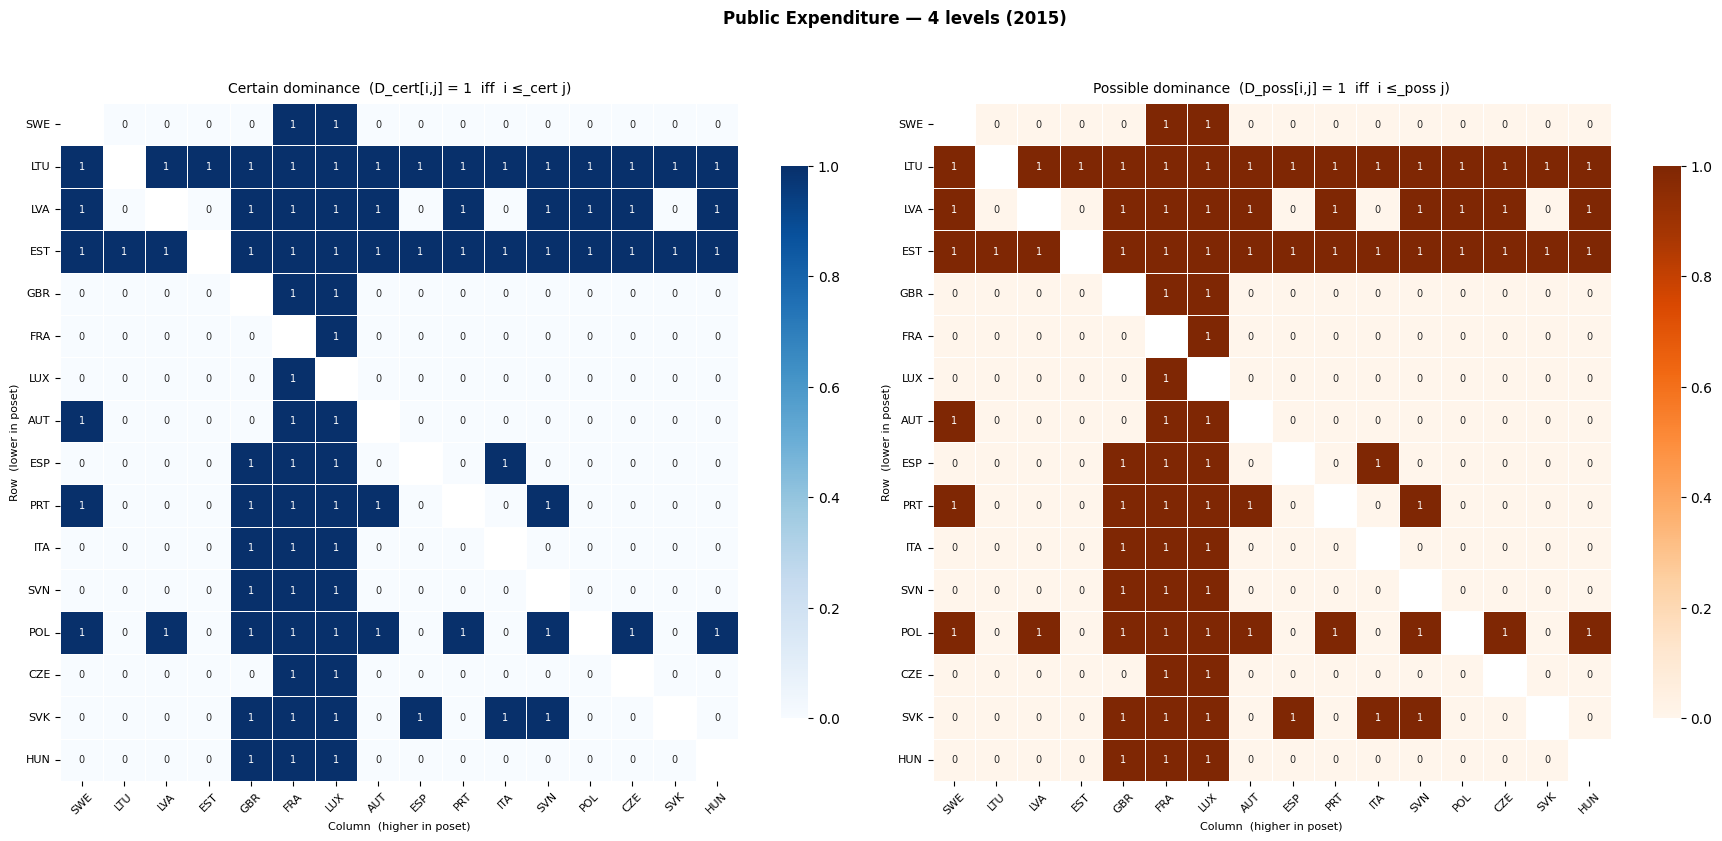

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [19]:
key = "exp_4lev_2015"
plot_certain_possible(
    poset_results[key], DATASETS[key]["label"],
    save_path="../img/080_dominance_matrices_exp_4lev_2015.png",
)

### 4.2 Public Expenditure — 4 levels (2018)

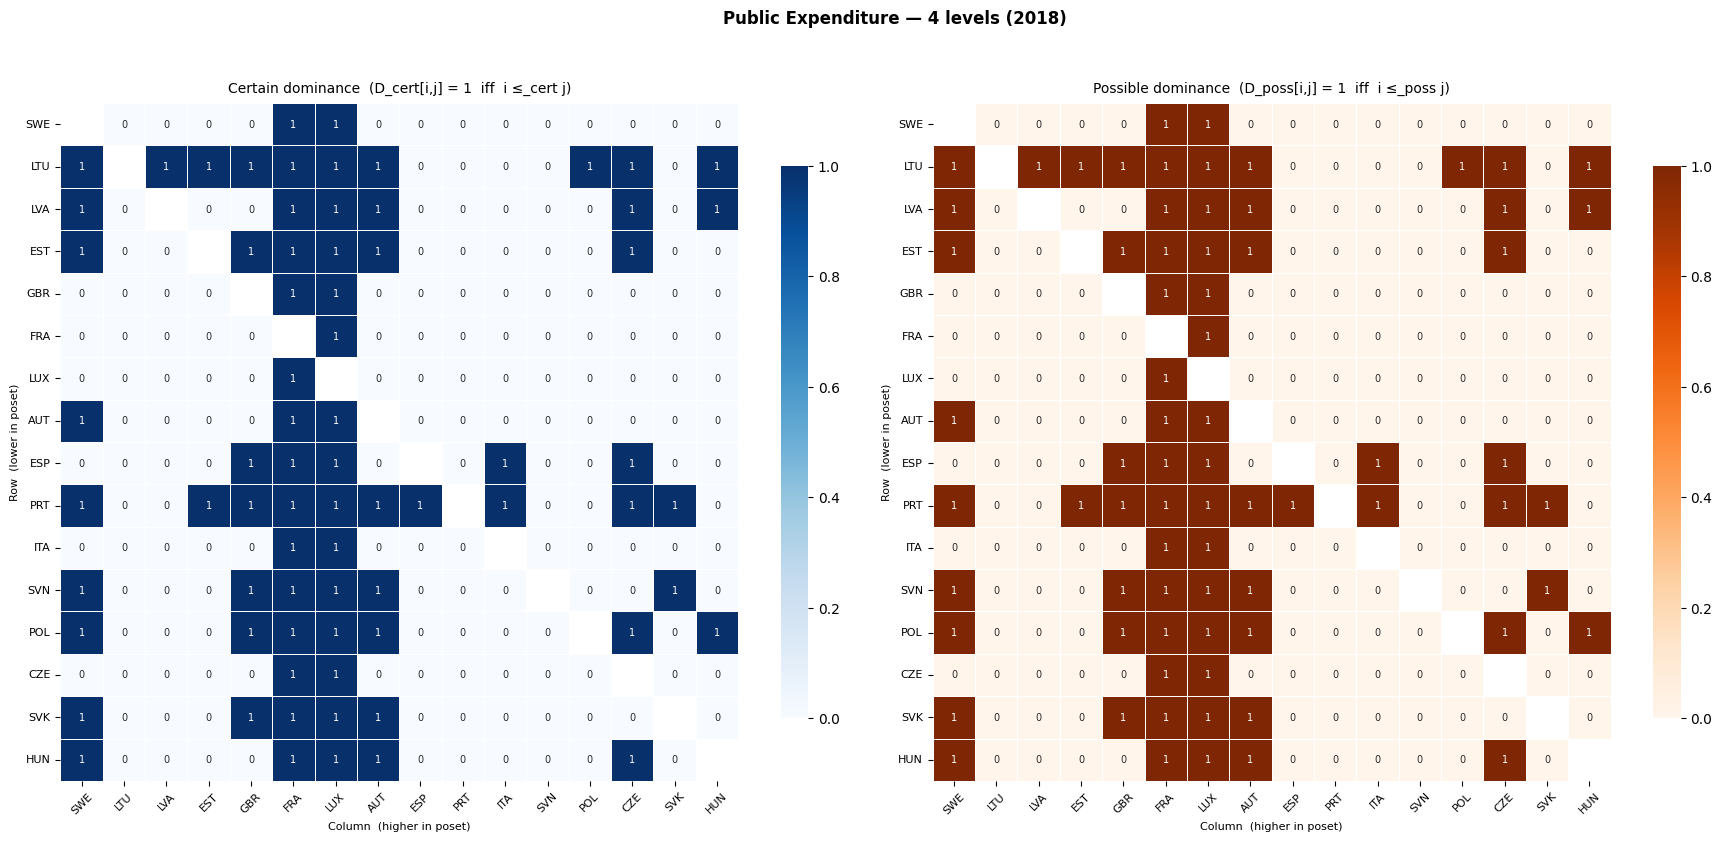

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [20]:
key = "exp_4lev_2018"
plot_certain_possible(
    poset_results[key], DATASETS[key]["label"],
    save_path="../img/080_dominance_matrices_exp_4lev_2018.png",
)

### 4.3 Indicators Macro-dim — 3 levels (2015)

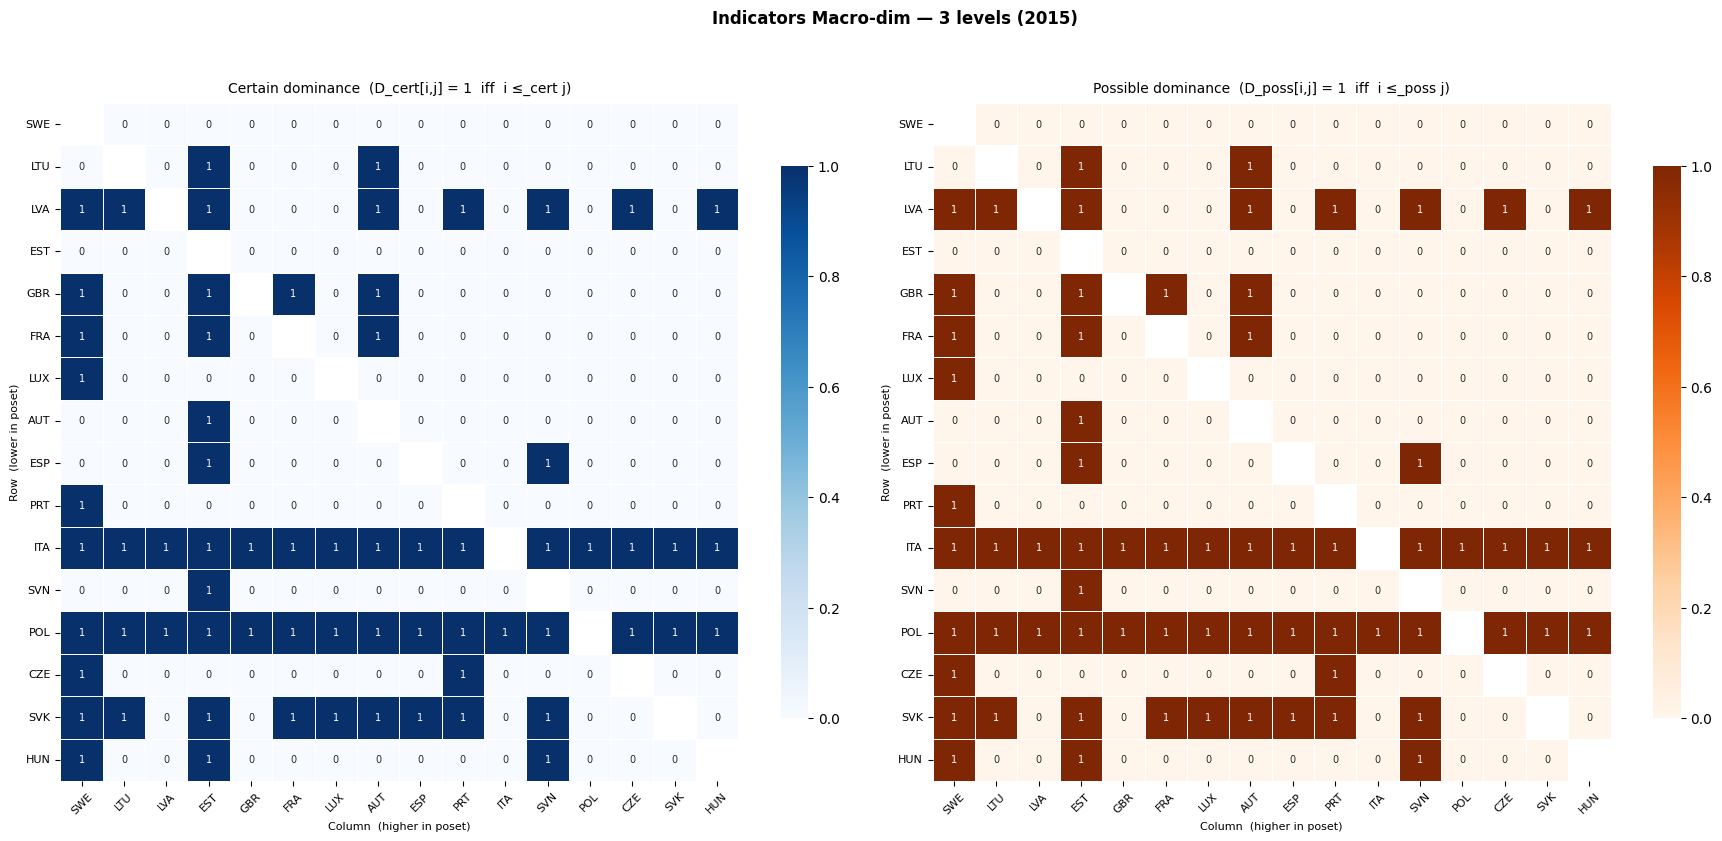

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [21]:
key = "ind_macro_3lev_2015"
plot_certain_possible(
    poset_results[key], DATASETS[key]["label"],
    save_path="../img/080_dominance_matrices_ind_macro_3lev_2015.png",
)

### 4.4 Indicators Macro-dim — 3 levels (2018)

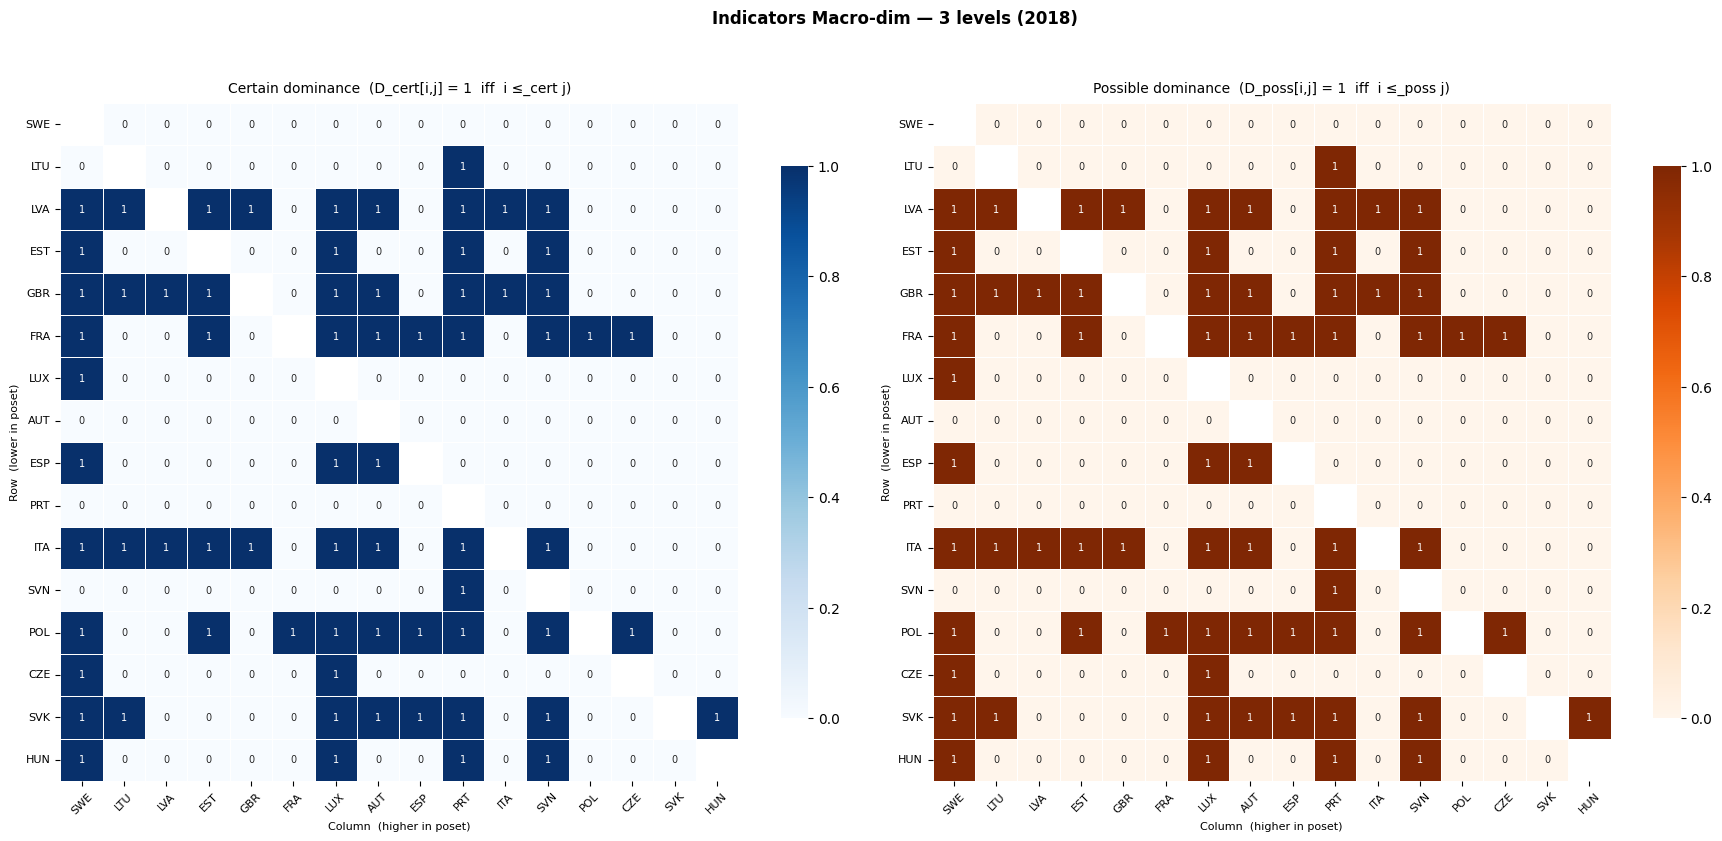

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [22]:
key = "ind_macro_3lev_2018"
plot_certain_possible(
    poset_results[key], DATASETS[key]["label"],
    save_path="../img/080_dominance_matrices_ind_macro_3lev_2018.png",
)

---
## 5. Posetic Separation matrices

The posetic separation $\text{Sep}(i,j)$ measures the expected normalised distance between the ranks  
of countries $i$ and $j$ averaged over all linear extensions of the poset:

$$\text{Sep}(i,j) = \frac{\mathbb{E}_{\sigma \sim \text{LE}(P)}\bigl[|\sigma(i) - \sigma(j)|\bigr]}{n - 1} \in [0, 1]$$

Approximated via **Bubley-Dyer MCMC** sampling (`N_SAMPLES` linear extensions per poset).  
The matrix is **symmetric** — no row/column directional interpretation.

- Value close to **1** → $i$ and $j$ consistently rank far apart (one near the top, one near the bottom)  
- Value close to **0** → $i$ and $j$ rank similarly in most linear extensions

---

In [23]:
N_SAMPLES = 50_000   # Bubley-Dyer samples per poset
SEED = 42

separations = {}
for key in DATASETS:
    result = poset_results[key]
    n = result["poset_certain"].n
    gen = P.BuildBubleyDyerSeparationGenerator(result["poset_certain"], SEED, "symmetric")
    sep_raw = gen.update(n=N_SAMPLES)["symmetric"]
    sep = sep_raw / (n - 1)
    np.fill_diagonal(sep, 0.0)
    separations[key] = (sep + sep.T) / 2   # enforce exact symmetry
    print(f"[{key}]  sep range: [{sep.min():.3f}, {sep.max():.3f}]  "
          f"mean off-diag: {sep[~np.eye(n, dtype=bool)].mean():.3f}")

[exp_4lev_2015]  sep range: [0.000, 1.000]  mean off-diag: 0.378
[exp_4lev_2018]  sep range: [0.000, 0.943]  mean off-diag: 0.378
[ind_macro_3lev_2015]  sep range: [0.000, 0.965]  mean off-diag: 0.378
[ind_macro_3lev_2018]  sep range: [0.000, 0.859]  mean off-diag: 0.378


### 5.1 Public Expenditure — 4 levels (2015)

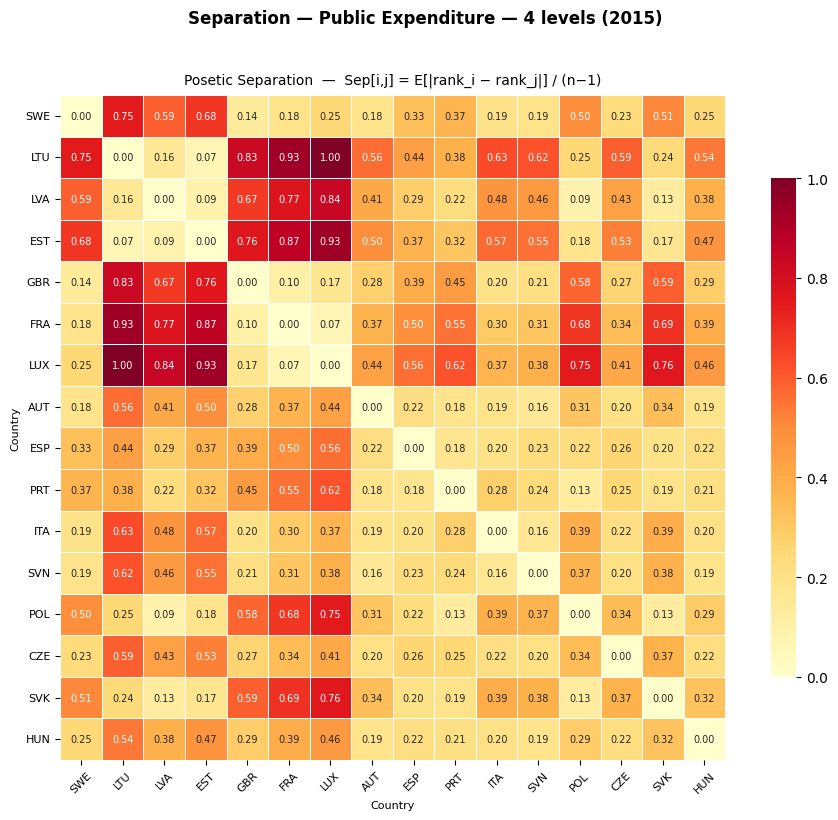

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Posetic Separation  —  Sep[i,j] = E[|rank_i − rank_j|] / (n−1)'}, xlabel='Country', ylabel='Country'>)

In [24]:
key = "exp_4lev_2015"
plot_separation(
    poset_results[key], separations[key], DATASETS[key]["label"],
    save_path="../img/080_separation_matrices_exp_4lev_2015.png",
)

### 5.2 Public Expenditure — 4 levels (2018)

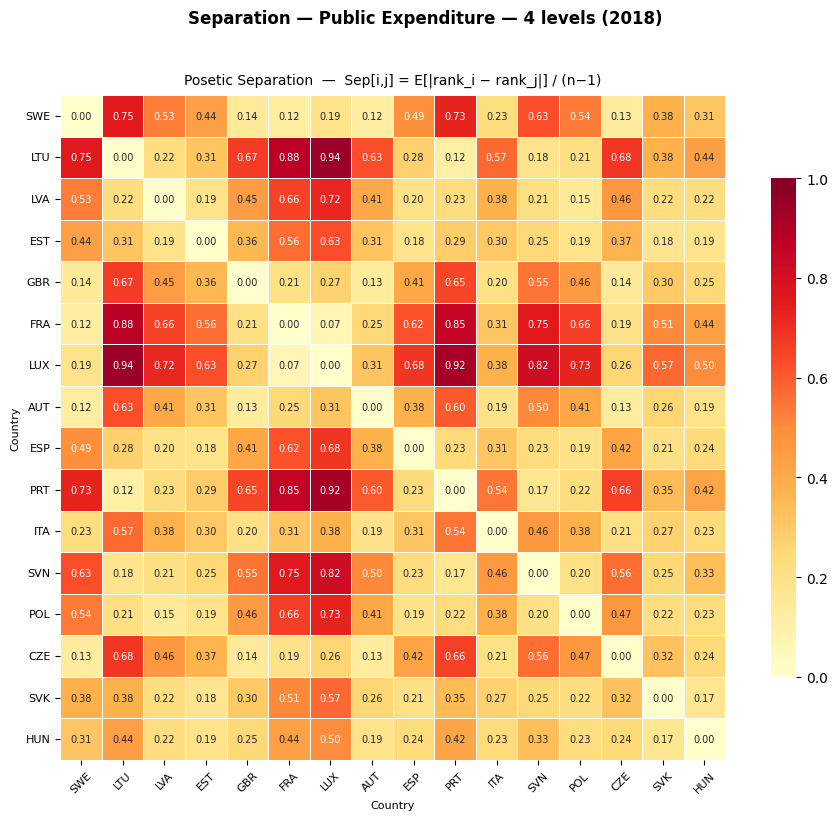

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Posetic Separation  —  Sep[i,j] = E[|rank_i − rank_j|] / (n−1)'}, xlabel='Country', ylabel='Country'>)

In [25]:
key = "exp_4lev_2018"
plot_separation(
    poset_results[key], separations[key], DATASETS[key]["label"],
    save_path="../img/080_separation_matrices_exp_4lev_2018.png",
)

### 5.3 Indicators Macro-dim — 3 levels (2015)

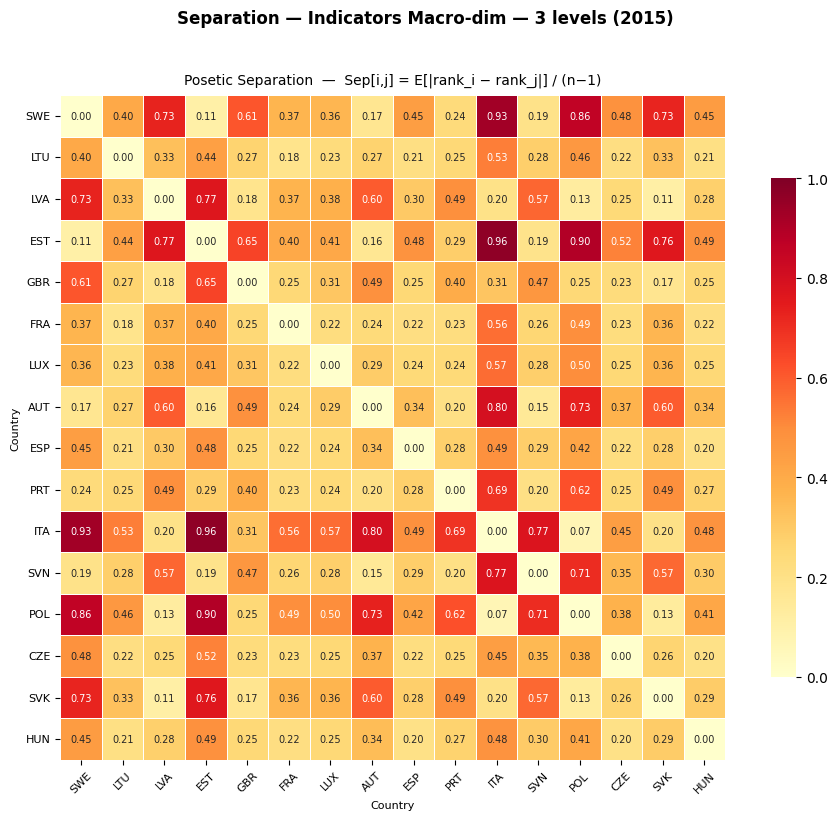

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Posetic Separation  —  Sep[i,j] = E[|rank_i − rank_j|] / (n−1)'}, xlabel='Country', ylabel='Country'>)

In [26]:
key = "ind_macro_3lev_2015"
plot_separation(
    poset_results[key], separations[key], DATASETS[key]["label"],
    save_path="../img/080_separation_matrices_ind_macro_3lev_2015.png",
)

### 5.4 Indicators Macro-dim — 3 levels (2018)

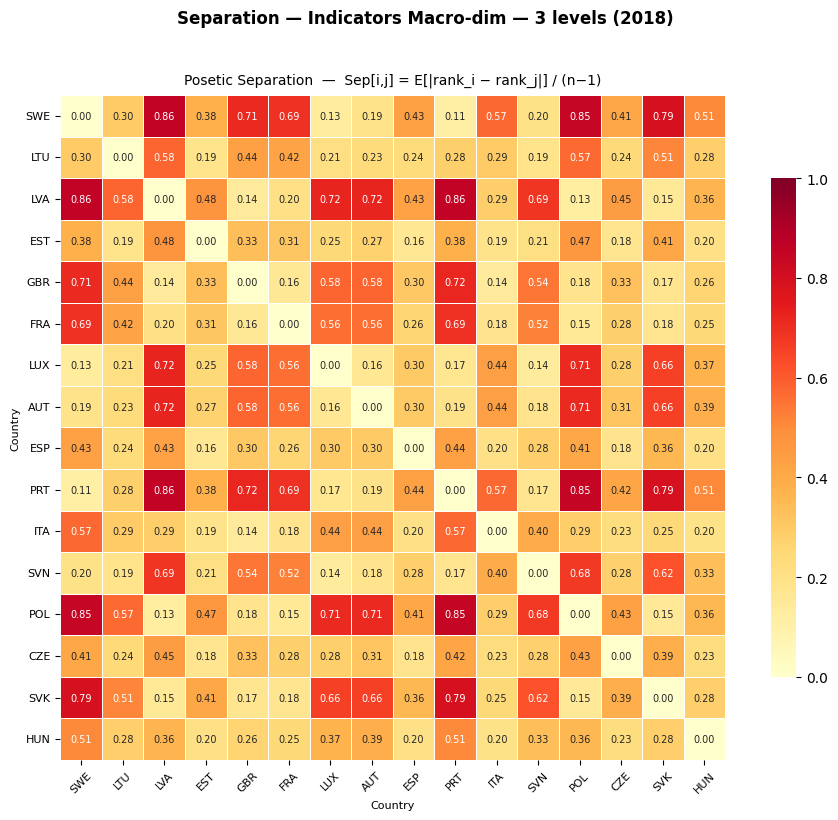

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Posetic Separation  —  Sep[i,j] = E[|rank_i − rank_j|] / (n−1)'}, xlabel='Country', ylabel='Country'>)

In [27]:
key = "ind_macro_3lev_2018"
plot_separation(
    poset_results[key], separations[key], DATASETS[key]["label"],
    save_path="../img/080_separation_matrices_ind_macro_3lev_2018.png",
)

---
## 6. Summary

Country-level aggregates: how many countries does each `REF_AREA` dominate (outbound)  
and how many times is it dominated (inbound), for both certain and possible posets.

In [28]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)

for key, meta in DATASETS.items():
    result = poset_results[key]
    elements = result["elements"]
    n = len(elements)

    cert_mat = result["poset_certain"].dominance_matrix().astype(int)
    poss_mat = result["poset_possible"].dominance_matrix().astype(int)
    np.fill_diagonal(cert_mat, 0)
    np.fill_diagonal(poss_mat, 0)

    sep = separations[key]

    rows = []
    for i, e in enumerate(elements):
        # Separation: mean and max against all other countries (exclude self)
        sep_row = np.concatenate([sep[i, :i], sep[i, i+1:]])
        rows.append({
            "country": e,
            "cert_outbound": int(cert_mat[i, :].sum()),
            "cert_inbound":  int(cert_mat[:, i].sum()),
            "poss_outbound": int(poss_mat[i, :].sum()),
            "poss_inbound":  int(poss_mat[:, i].sum()),
            "sep_mean": round(float(sep_row.mean()), 3),
            "sep_max":  round(float(sep_row.max()), 3),
        })

    summary_df = (
        pl.DataFrame(rows)
        .sort("sep_mean", descending=True)
    )

    print(f"\n{'='*60}")
    print(f"  {meta['label']}")
    print(f"  cert_outbound/inbound = certain dominance count")
    print(f"  sep_mean = avg separation from all other countries")
    print(f"  sep_max  = max separation (most distant opponent)")
    print(f"{'='*60}")
    display(summary_df)


  Public Expenditure — 4 levels (2015)
  cert_outbound/inbound = certain dominance count
  sep_mean = avg separation from all other countries
  sep_max  = max separation (most distant opponent)


country,cert_outbound,cert_inbound,poss_outbound,poss_inbound,sep_mean,sep_max
str,i64,i64,i64,i64,f64,f64
"""LTU""",15,1,15,1,0.533,1.0
"""LUX""",1,15,1,15,0.533,1.0
"""EST""",15,1,15,1,0.471,0.933
"""FRA""",1,15,1,15,0.471,0.933
"""LVA""",10,3,10,3,0.401,0.841
"""GBR""",2,10,2,10,0.396,0.831
"""SVK""",6,2,6,2,0.361,0.76
"""SWE""",2,6,2,6,0.357,0.749
"""POL""",10,3,10,3,0.348,0.749



  Public Expenditure — 4 levels (2018)
  cert_outbound/inbound = certain dominance count
  sep_mean = avg separation from all other countries
  sep_max  = max separation (most distant opponent)


country,cert_outbound,cert_inbound,poss_outbound,poss_inbound,sep_mean,sep_max
str,i64,i64,i64,i64,f64,f64
"""LUX""",1,15,1,15,0.533,0.943
"""LTU""",10,0,10,0,0.484,0.943
"""FRA""",1,15,1,15,0.471,0.876
"""PRT""",10,0,10,0,0.465,0.919
"""SVN""",6,0,6,0,0.406,0.82
"""SWE""",2,9,2,9,0.383,0.752
"""POL""",7,1,7,1,0.351,0.728
"""CZE""",2,7,2,7,0.35,0.682
"""LVA""",6,1,6,1,0.349,0.722



  Indicators Macro-dim — 3 levels (2015)
  cert_outbound/inbound = certain dominance count
  sep_mean = avg separation from all other countries
  sep_max  = max separation (most distant opponent)


country,cert_outbound,cert_inbound,poss_outbound,poss_inbound,sep_mean,sep_max
str,i64,i64,i64,i64,f64,f64
"""ITA""",15,1,15,1,0.533,0.965
"""EST""",0,11,0,11,0.502,0.965
"""SWE""",0,10,0,10,0.471,0.927
"""POL""",15,1,15,1,0.471,0.898
"""AUT""",1,7,1,7,0.384,0.8
"""LVA""",8,2,8,2,0.379,0.766
"""SVK""",9,2,9,2,0.377,0.764
"""SVN""",1,6,1,6,0.373,0.773
"""PRT""",1,5,1,5,0.342,0.691



  Indicators Macro-dim — 3 levels (2018)
  cert_outbound/inbound = certain dominance count
  sep_mean = avg separation from all other countries
  sep_max  = max separation (most distant opponent)


country,cert_outbound,cert_inbound,poss_outbound,poss_inbound,sep_mean,sep_max
str,i64,i64,i64,i64,f64,f64
"""PRT""",0,10,0,10,0.477,0.859
"""SWE""",0,11,0,11,0.476,0.858
"""LVA""",9,2,9,2,0.471,0.859
"""POL""",9,1,9,1,0.462,0.848
"""SVK""",8,0,8,0,0.426,0.792
"""AUT""",0,7,0,7,0.394,0.724
"""LUX""",1,10,1,10,0.38,0.725
"""GBR""",9,2,9,2,0.373,0.716
"""FRA""",9,1,9,1,0.362,0.695


*This notebook is licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).*